### SweebApp - Model for phishing detection 🤖

In the next phase of the project, two different machine learning approaches will be implemented and evaluated in order to solve the URL phishing detection problem.

# 1. Classical Machine Learning Model (Tabular Data)

The first approach consists of building a classification model using **scikit-learn's RandomForestClassifier**, trained on the structured dataset created during the preprocessing phase.
This dataset contains engineered numerical features extracted from URLs, such as:

* URL length
* number of dots and slashes
* domain characteristics
* presence of suspicious patterns

The Random Forest model was chosen due to its robustness, ability to handle tabular data efficiently, and strong performance without requiring feature normalization.

# 2. NLP-Based Model (Transformer – URLBERT)

The second approach uses a pre-trained transformer model, specifically **CrabInHoney/urlbert-tiny-v5**, which is designed to work directly with raw URL text.

The model will be fine-tuned using transfer learning on the text-based dataset prepared earlier (containing raw URLs and their corresponding labels).

Key Specifications :

* **Architecture**: DistilBERT (6 layers, 768 hidden dimensions, 12 attention heads)
* **Parameters**: ~58.2M
* **Context Window**: 512 tokens
* **Vocabulary Size**: 19,996
* **Tensor type**: F32

Model can be download from : https://huggingface.co/CrabInHoney/urlbert-tiny-v5

# 1. Classical Machine Learning Model (Tabular Data)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
sweeb_tubular_dataset = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/sweeb_phishing_dataset.csv")

In [3]:
sweeb_tubular_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1207305 entries, 0 to 1207304
Data columns (total 10 columns):
 #   Column                   Non-Null Count    Dtype
---  ------                   --------------    -----
 0   suspicious_char_path     1207305 non-null  int64
 1   len_path                 1207305 non-null  int64
 2   top_tld                  1207305 non-null  int64
 3   suspicious_word_domain   1207305 non-null  int64
 4   num_special_char_domain  1207305 non-null  int64
 5   https_protocol           1207305 non-null  int64
 6   num_slash                1207305 non-null  int64
 7   num_dots                 1207305 non-null  int64
 8   url_length               1207305 non-null  int64
 9   is_threat_threat         1207305 non-null  bool 
dtypes: bool(1), int64(9)
memory usage: 84.1 MB


In [4]:
sweeb_tubular_dataset.head(10)

,suspicious_char_path,len_path,top_tld,suspicious_word_domain,num_special_char_domain,https_protocol,num_slash,num_dots,url_length,is_threat_threat
0,1,6,0,0,0,1,3,1,36,False
1,0,20,1,0,0,1,5,3,56,False
2,0,11,0,0,0,1,3,1,41,False
3,0,11,1,0,0,1,3,3,47,False
4,0,1,0,1,0,1,3,2,38,False
5,0,11,0,0,0,1,3,1,41,False
6,0,6,0,1,0,1,3,2,43,False
7,0,20,1,0,0,1,5,3,52,False
8,1,13,1,0,0,1,3,3,45,False
9,0,13,0,1,0,1,4,2,50,False


In [5]:
sweeb_tubular_dataset = sweeb_tubular_dataset.drop('num_special_char_domain', axis=1)

In [6]:
sweeb_tubular_dataset.head(1)

,suspicious_char_path,len_path,top_tld,suspicious_word_domain,https_protocol,num_slash,num_dots,url_length,is_threat_threat
0,1,6,0,0,1,3,1,36,False


In [7]:
# Create X (features)
X = sweeb_tubular_dataset.drop('is_threat_threat', axis=1)

# Create y (labels)
y = sweeb_tubular_dataset['is_threat_threat']

X.head(10)

,suspicious_char_path,len_path,top_tld,suspicious_word_domain,https_protocol,num_slash,num_dots,url_length
0,1,6,0,0,1,3,1,36
1,0,20,1,0,1,5,3,56
2,0,11,0,0,1,3,1,41
3,0,11,1,0,1,3,3,47
4,0,1,0,1,1,3,2,38
5,0,11,0,0,1,3,1,41
6,0,6,0,1,1,3,2,43
7,0,20,1,0,1,5,3,52
8,1,13,1,0,1,3,3,45
9,0,13,0,1,1,4,2,50


In [8]:
y.head(10)

,is_threat_threat
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [9]:
# Model
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [10]:
# Setup random seed
np.random.seed(42)

In [11]:
# Fit the model to the training data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

len(X_train), len(y_train), len(X_test), len(y_test)

(965844, 965844, 241461, 241461)

In [12]:
clf.fit(X_train, y_train)

RandomForestClassifier()

In [13]:
y_pred = clf.predict(X_test)

In [14]:
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score , ConfusionMatrixDisplay

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.60      0.78      0.68    118124
        True       0.71      0.50      0.59    123337

    accuracy                           0.64    241461
   macro avg       0.66      0.64      0.64    241461
weighted avg       0.66      0.64      0.63    241461



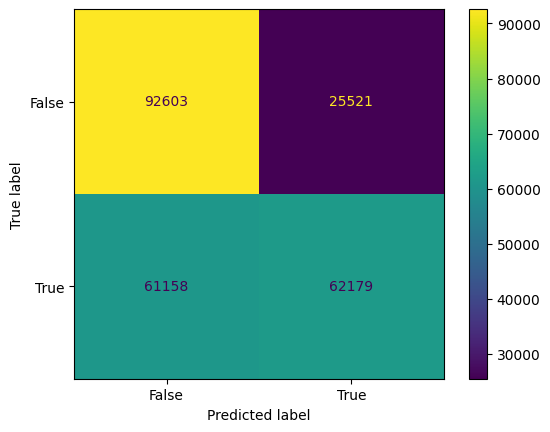

In [15]:
cm = confusion_matrix(y_test,y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

# 2. NLP-Based Model (Transformer – URLBERT)

In [1]:
# Imports
import torch
import os
from datasets import load_dataset
from peft import get_peft_model, LoraConfig, prepare_model_for_kbit_training
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer

In [2]:
!nvidia-smi

Sat May  2 22:20:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   37C    P5              4W /  180W |    1922MiB /   8151MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
model_name = "CrabInHoney/urlbert-tiny-v5"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: CrabInHoney/urlbert-tiny-v5
Key                   | Status  | 
----------------------+---------+-
pre_classifier.weight | MISSING | 
classifier.bias       | MISSING | 
classifier.weight     | MISSING | 
pre_classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
print(model.get_memory_footprint()/1e6)

235.488264


In [7]:
print(model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(19996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [8]:
# Setting up Low - Rank Adapters (LoRA)

model = prepare_model_for_kbit_training(model)

config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["k_lin","v_lin"]
)

model = get_peft_model(model, config)

model

PeftModel(
  (base_model): LoraModel(
    (model): DistilBertForSequenceClassification(
      (distilbert): DistilBertModel(
        (embeddings): Embeddings(
          (word_embeddings): Embedding(19996, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (transformer): Transformer(
          (layer): ModuleList(
            (0-5): 6 x TransformerBlock(
              (attention): DistilBertSelfAttention(
                (q_lin): Linear(in_features=768, out_features=768, bias=True)
                (k_lin): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Identity()
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=8, bias

In [9]:
print(model.get_memory_footprint()/1e6)

236.078088


In [10]:
dataset_path = "C:\\Users\\CprAlin\\Documents\\datasets\\sweeb_phishing_nlp_dataset.csv"

In [13]:
sweeb_nlp_dataset = pd.read_csv(dataset_path)

In [25]:
sweeb_nlp_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1207305 entries, 0 to 1207304
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   url        1207305 non-null  object
 1   is_threat  1207305 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 18.4+ MB


In [14]:
sweeb_nlp_dataset.head(10)

,url,is_threat
0,https://webmail.corp/login?id=385071,0
1,https://portal.example.org/owa/auth/logon.aspx...,0
2,https://webmail.corp/phpmyadmin?id=114701,0
3,https://portal.example.org/config.php?id=345569,0
4,https://internal.bank.local/?id=432022,0
5,https://webmail.corp/phpmyadmin?id=957608,0
6,https://internal.bank.local/admin?id=567716,0
7,https://api.service.io/owa/auth/logon.aspx?id=...,0
8,https://api.service.io/wp-login.php?id=407810,0
9,https://internal.bank.local/manager/html?id=20...,0


In [49]:
sweeb_nlp_dataset["is_threat"].value_counts()

is_threat
1    772703
0    434602
Name: count, dtype: int64

In [15]:
dataset = load_dataset("csv", data_files=dataset_path)

dataset

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['url', 'is_threat'],
        num_rows: 1207305
    })
})

In [16]:
url = sweeb_nlp_dataset["url"][1]
url

'https://portal.example.org/owa/auth/logon.aspx?id=280743'

In [17]:
input = tokenizer(url, truncation=True, max_length=512,padding="max_length")

In [18]:
input

{'input_ids': [2, 263, 30, 19, 19, 9896, 18, 888, 18, 844, 19, 8909, 89, 19, 1087, 19, 5804, 98, 18, 9329, 35, 358, 33, 14328, 2784, 82, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [19]:
def tokenize(batch):
  return tokenizer(
      batch["url"],
      truncation=True,
      max_length=512,
      padding="max_length"
  )

In [20]:
print(type(dataset["train"][0]["url"]))

<class 'str'>


In [21]:
dataset = dataset.rename_column("is_threat","label")

In [22]:
dataset

DatasetDict({
    train: Dataset({
        features: ['url', 'label'],
        num_rows: 1207305
    })
})

In [23]:
dataset = dataset.map(tokenize, batched=True, remove_columns=["url"])

Map:   0%|          | 0/1207305 [00:00<?, ? examples/s]

In [24]:
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1207305
    })
})

In [51]:
small_train = dataset["train"].shuffle(seed=42).select(range(50000))
small_test = dataset["train"].shuffle(seed=42).select(range(10000))

In [52]:
small_train

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 50000
})

In [53]:
small_test

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 10000
})

In [54]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = logits.argmax(axis=1)

  precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")

  acc = accuracy_score(labels, preds)

  return {
      "accuracy" : acc,
      "f1" : f1,
      "precision" : precision,
      "recall" : recall
  }

In [55]:
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Colab Notebooks/results_sweeb_model",
    learning_rate=2e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

In [56]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    compute_metrics=compute_metrics
)

In [57]:
import datetime as dt
time = dt.datetime.now()

In [45]:
print(time.strftime("%Y-%m-%d %H:%M"))
trainer.train()
print(time.strftime("%Y-%m-%d %H:%M"))

2026-05-02 22:33


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.562958,0.547369,0.663857,0.765801,0.691533,0.857939
2,0.546308,0.526594,0.677571,0.741792,0.761569,0.723015
3,0.535230,0.513972,0.680857,0.733413,0.788758,0.685326
4,0.516736,0.503716,0.690571,0.743365,0.792973,0.699599
5,0.512651,0.491131,0.692429,0.718746,0.867550,0.613515
6,0.499594,0.481049,0.703857,0.764030,0.780284,0.748439
7,0.492082,0.474634,0.716571,0.764873,0.816136,0.719670
8,0.494377,0.471370,0.720286,0.750637,0.875000,0.657226
9,0.487229,0.467233,0.725429,0.771842,0.825127,0.725022
10,0.479804,0.455309,0.732571,0.771429,0.852402,0.704505


2026-05-02 22:33


In [46]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.442831,0.415146,20,0.772000,0.807200,0.880601,0.745094


{'eval_loss': 0.4151461124420166,
 'eval_accuracy': 0.772,
 'eval_f1': 0.8071998067165982,
 'eval_precision': 0.8806009488666315,
 'eval_recall': 0.7450936663693131}

In [47]:
sweeb_nlp_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1207305 entries, 0 to 1207304
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   url        1207305 non-null  str  
 1   is_threat  1207305 non-null  int64
dtypes: int64(1), str(1)
memory usage: 82.7 MB
